# Caso 3 — Modelo Probabilístico (BM25)

Este notebook implementa o **BM25 (Okapi BM25)** manualmente — o cálculo do
score é feito termo a termo, documento a documento, usando um índice
invertido próprio (`src/bm25.py`). Nenhuma biblioteca que "esconda" o
cálculo do score (ex.: `rank_bm25`, Elasticsearch, Whoosh) é utilizada.


In [1]:
from pathlib import Path
import sys
project_root = Path.cwd()
if not (project_root / "src").is_dir() and (project_root.parent / "src").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from src.cranfield_data import load_cranfield
from src.pre_processing import load_preprocessed
from src.bm25 import BM25

df_docs, df_queries, df_qrels = load_cranfield()
preprocessed = load_preprocessed(project_root / "data" / "processed" / "preprocessed_cranfield.pkl")

CONFIG = "stopwords_stemming"  # mesma configuração usada no Caso 2, ver justificativa lá
doc_tokens = preprocessed[CONFIG]["docs"]
query_tokens_list = preprocessed[CONFIG]["queries"]

doc_ids = df_docs["doc_id"].tolist()
query_ids = df_queries["query_id"].tolist()
doc_title = dict(zip(df_docs.doc_id, df_docs.title.str.replace("\n", " ")))


[cranfield_data] ir_datasets indisponível (RuntimeError: ('All download sources failed', [(RequestsDownload('http://ir.dcs.gla.ac.uk/resources/test_collections/cran/cran.tar.gz', tries=None), HTTPError('403 Client Error: Forbidden for url: http://ir.dcs.gla.ac.uk/resources/test_collections/cran/cran.tar.gz')), (RequestsDownload('https://mirror.ir-datasets.com/1730f7be572d95a5a4b56c59a7b900a5', tries=None), HTTPError('403 Client Error: Forbidden for url: https://mirror.ir-datasets.com/1730f7be572d95a5a4b56c59a7b900a5'))])). Usando arquivos locais em data/raw/ como fallback.


[WARNING] Download failed: 403 Client Error: Forbidden for url: http://ir.dcs.gla.ac.uk/resources/test_collections/cran/cran.tar.gz
[WARNING] Download failed: 403 Client Error: Forbidden for url: https://mirror.ir-datasets.com/1730f7be572d95a5a4b56c59a7b900a5


## Construção do índice

In [2]:
# Construção do índice BM25
#
# BM25(D,Q) = sum_{t em Q} idf(t) * (f(t,D)*(k1+1)) / (f(t,D) + k1*(1-b+b*|D|/avgdl))
# idf(t)    = ln(1 + (N - df(t) + 0.5) / (df(t) + 0.5))
#
# Parâmetros padrão: k1=1.2, b=0.75 (valores clássicos da literatura; serão
# variados sistematicamente no Caso 7). O índice invertido (termo -> lista
# de documentos que o contêm) é construído uma única vez; k1 e b podem ser
# alterados via `set_params` sem reconstruir o índice.
bm25 = BM25(doc_tokens, k1=1.2, b=0.75)
print(f"N documentos: {bm25.n_docs}")
print(f"Comprimento médio dos documentos (avgdl): {bm25.avgdl:.2f} tokens")
print(f"Termos no índice invertido: {len(bm25.inverted_index)}")


N documentos: 1400
Comprimento médio dos documentos (avgdl): 92.07 tokens
Termos no índice invertido: 4292


## Exemplo de recuperação

Mesma consulta usada no Caso 2 (Modelo Vetorial), para permitir uma
comparação visual direta antes da avaliação quantitativa formal (Caso 4).
Note que a ordem já difere ligeiramente da do Modelo Vetorial mesmo nesta
consulta simples.


In [3]:
# Exemplo: ranking para a mesma consulta usada no Caso 2, para comparação direta
query_id_0 = query_ids[0]
print(f"Consulta {query_id_0}: {df_queries.iloc[0]['text']}")
print()

ranking = bm25.rank(query_tokens_list[0], top_n=10)
grades = dict(zip(df_qrels[df_qrels.query_id == query_id_0].doc_id,
                   df_qrels[df_qrels.query_id == query_id_0].relevance))
rows = []
for rank, (doc_idx, score) in enumerate(ranking, start=1):
    did = doc_ids[doc_idx]
    grade = grades.get(did, None)
    rows.append({
        "rank": rank, "doc_id": did, "score_bm25": round(score, 4),
        "grau_relevancia": grade if grade is not None else "não julgado",
        "titulo": doc_title[did][:80],
    })
display(pd.DataFrame(rows))


Consulta 1: what similarity laws must be obeyed when constructing aeroelastic models
of heated high speed aircraft .



,rank,doc_id,score_bm25,grau_relevancia,titulo
0,1,51,21.4787,3,theory of aircraft structural models subjected...
1,2,486,20.2663,-1,similarity laws for aerothermoelastic testing .
2,3,12,18.1942,3,some structural and aerelastic considerations ...
3,4,184,16.9551,2,scale models for thermo-aeroelastic research .
4,5,573,16.4571,não julgado,viscous hypersonic similitude .
5,6,878,16.3198,não julgado,experimental model techniques and equipment fo...
6,7,665,13.8199,não julgado,on the theory of hypersonic gas flow with a po...
7,8,944,12.4994,não julgado,one dimensional heat conduction through the sk...
8,9,141,12.3896,não julgado,free-flight techniques for high speed aerodyna...
9,10,746,12.3881,não julgado,aeroelastic problems in connection with high s...


## Papel de k1 e b na fórmula

Antes da variação sistemática de parâmetros (Caso 7), vale visualizar o
que k1 faz isoladamente: ele controla a rapidez com que a contribuição de
um termo "satura" à medida que sua frequência no documento aumenta. Com
k1 baixo (0.5), a curva satura quase imediatamente (poucas repetições já
dão quase todo o benefício possível); com k1 alto (2.0), a curva continua
crescendo por mais tempo antes de estabilizar. Esse comportamento —
ausente no Modelo Vetorial, onde o tf log-normalizado cresce de forma mais
suave e sem um teto tão pronunciado — é um dos pontos centrais da
comparação nos casos seguintes.


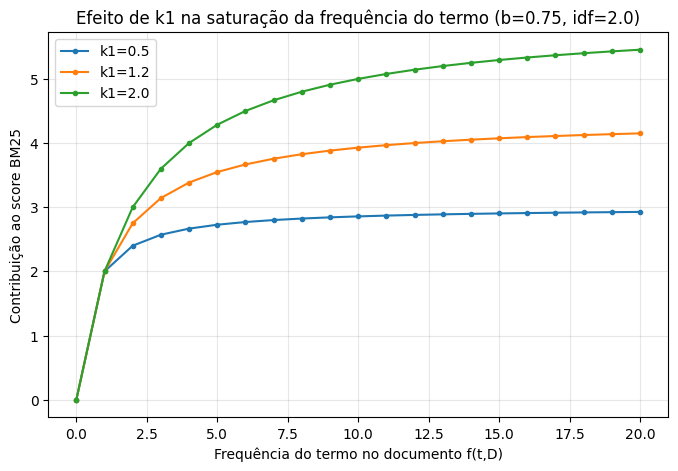

In [4]:
# Ilustração do efeito de k1 e b no score de UM documento
#
# k1 controla a saturação da frequência do termo (quanto repetir um termo
# ajuda, com retornos decrescentes); b controla o quanto o comprimento do
# documento é penalizado em relação à média da coleção. Abaixo, o score de
# um termo hipotético com idf fixo, variando sua frequência no documento,
# para diferentes valores de k1 (documento do tamanho médio da coleção).
idf_exemplo = 2.0
avgdl = bm25.avgdl
freqs = np.arange(0, 21)

plt.figure(figsize=(8, 5))
for k1_val in [0.5, 1.2, 2.0]:
    scores = idf_exemplo * (freqs * (k1_val + 1)) / (freqs + k1_val * (1 - 0.75 + 0.75 * (avgdl / avgdl)))
    plt.plot(freqs, scores, marker="o", markersize=3, label=f"k1={k1_val}")
plt.xlabel("Frequência do termo no documento f(t,D)")
plt.ylabel("Contribuição ao score BM25")
plt.title("Efeito de k1 na saturação da frequência do termo (b=0.75, idf=2.0)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
